# Decoding PicoQuant TTTR Files (.ptu) and Fit Fluorescence Decays

This script deals with decoding of PicoQuant TTTR files (.ptu) produced by HydraHarp V2. First, the header section is decoded to gain necessary information for proper decoding of the photon record data and the actual microscope image, i.e. the position in x and y where a particular photon record was made. Second, the photon recond data are read and sorted into a 3D array. This array holds the fluorescence decay curves of each pixel and are subsequently fitted to obtain fluorescence lifetimes.

**In this script, only HydraHarp V2 TTTR data are treated and decoded. However, it can easily be expanded to also cover different PicoQuant TCSPC hardware.**

This script is based on PicoQuants' .ptu decoding example (https://github.com/PicoQuant/PicoQuant-Time-Tagged-File-Format-Demos/blob/master/PTU/Python/Read_PTU.py) and an adaption of that script for the PhasorFLIM application written in JavaScript (https://github.com/Tomkaehst/PhasorFLIM/blob/master/app/filedecoding/PTUReaderBitwise.js).


## PTU File Architecture

*.ptu* files consist of a header and record section. In the header, information about the FLIM system and imaging parameters are stored, which are required in order to reconstruct FLIM images from the single photon data encoded in the record section.

### File Magic

*.ptu* files can be identified and verified by the file magic string encoded in the first eight bytes. It should read ```PQTTTR```. The next eight bytes contain the file version (see ).

After file verification, header tags of different data types are read out. The header end is indicated by "Header_End" and can be searched for to know when to stop decoding it. Header data types are indicated by type code tags in each 48 byte header data piece. It is checked to decide what data type should be extracted from the binary file. To read the photon record data from the following file section, the record type has to be known. This is also encoded in the header section.

In [1]:
import sys, struct, io, os
import math
import numpy as np
import time # For measuring code performance
%matplotlib inline 
import matplotlib.pyplot as plt

ptupath = 'testData/2016-10-28_FLIM1_1_1.ptu'
ptureadstream = open(ptupath, 'rb')

filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

# Checking file valiidy by reading file magic and file version
if(filemagic != 'PQTTTR'):
    print('%s is not a .ptu file!' % ptupath)
    ptureadstream.close()
else:
    print('%s is a valid .ptu file... Commencing.' % ptupath)

    
fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
print('File Version: %s' % fileversion)

testData/2016-10-28_FLIM1_1_1.ptu is a valid .ptu file... Commencing.
File Version: 00.0.1


In [2]:
# Definition of header tag types

tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

# Defining record types

rtPicoHarpT3     = struct.unpack(">i", bytes.fromhex('00010303'))[0]
rtPicoHarpT2     = struct.unpack(">i", bytes.fromhex('00010203'))[0]
rtHydraHarpT3    = struct.unpack(">i", bytes.fromhex('00010304'))[0]
rtHydraHarpT2    = struct.unpack(">i", bytes.fromhex('00010204'))[0]
rtHydraHarp2T3   = struct.unpack(">i", bytes.fromhex('01010304'))[0]
rtHydraHarp2T2   = struct.unpack(">i", bytes.fromhex('01010204'))[0]
rtTimeHarp260NT3 = struct.unpack(">i", bytes.fromhex('00010305'))[0]
rtTimeHarp260NT2 = struct.unpack(">i", bytes.fromhex('00010205'))[0]
rtTimeHarp260PT3 = struct.unpack(">i", bytes.fromhex('00010306'))[0]
rtTimeHarp260PT2 = struct.unpack(">i", bytes.fromhex('00010206'))[0]
rtMultiHarpNT3   = struct.unpack(">i", bytes.fromhex('00010307'))[0]
rtMultiHarpNT2   = struct.unpack(">i", bytes.fromhex('00010207'))[0]

## Decoding Header Information
In the first file segment, information about the measurement are encoded in different data types (see PicoQuant TTTR documententation in GitHub repository above).
Each header piece has 48 bytes. 

- 0:32 holds the tag ID (e.g. filename, image dimensions, ...)
- 32:36 holds the tag index
- 36:40 holds tag data type identifier (see above)
- 40:48 holds actual tag value

The header is read in 48 byte chunks until the header end tag is encounterd. The detected tag data type decides how a header piece is treated. If a string is identified, the tag value variable indicates in how many bytes the string in encoded. After treatment, header chunks are stored in the header_contents dictionary.

In [3]:
## setting up header end string to terminate header decoding in while loop 
headerend_tag = 'Header_End'
reached_headerend = False


# tuple that stores decoded information from header section
header_contents = {}

# decoding header
while(reached_headerend == False):
    headerpiece = ptureadstream.read(48)
    tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
    tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
    tagType = struct.unpack('<i', headerpiece[36:40])[0]
    tagVal = headerpiece[40:48]
    
    if(tagId == headerend_tag):
        reached_headerend = True
        ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
        print('Found Header_End.')
        break
    
    if(tagType == tyEmpty8):
        header_contents['Empty'] =  'Empty'
        
    elif(tagType == tyBool8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyInt8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8):
        value = struct.unpack('<d', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyFloat8Array):
        value = struct.unpack("<q", tagVal)[0]
        print('Float array with %d entries' % value / 8)
        
    elif(tagType == tyAnsiString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('latin1').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyWideString):
        value = struct.unpack('<q', tagVal)[0]
        string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
        header_contents[tagId] =  string
    
    elif(tagType == tyBinaryBlob):
        value = struct.unpack("<q", tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyBitSet64):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value
        
    elif(tagType == tyColor8):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  "{0:#0{1}x}".format(value,18)
        
    elif(tagType == tyBinaryBlob):
        value = struct.unpack('<q', tagVal)[0]
        header_contents[tagId] =  value

    elif(tagType == tyTDateTime):
        print(' ')
        
    else:
        continue
        #print('Unknown header tag type. Ignored.')
        
    
headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header
    
print('Finished header decoding.')

 
Found Header_End.
Finished header decoding.


The releveant header information is now copied into a new structure for convinient access.
In order to reconstruct the FLIM image, several value are required

- Filename: Filename
- Comment: String containing user comments
- TTResultsFormat_TTTRRecType: Type of the photon records i.e. which device was used
- TTResultFormat_BitsPerRecord: Number of bits in a photon record
- ReqHdr_SpatialResolution: Width of a pixel in µm
- ImgHdr_PixX: How many pixels in X?
- ImgHdr_PixY: How many pixels in Y?
- MeasDesc_GlobalResolution: time resolution of measurement
- HW_BaseResolution: Principal time resolution of device
- MeasDesc_Resolution: TCSPC resolution, also obtained by BaseResolution * BinningFactor
- MeasDesc_BinningFactor: Binning factor
- TTResult_SyncRate: Laser pulse / Sync rate of measurement
- TTResult_NumberOfRecords: How many 32 bit records in file?

In [4]:
FLIMInfo = {
    'Filename' : header_contents['$Filename'],
    'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
    'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
    'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
    'PixelsX' : header_contents['ImgHdr_PixX'],
    'PixelsY' : header_contents['ImgHdr_PixY'],
    'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
    'BaseResolution' : header_contents['HW_BaseResolution'],
    'Resolution' : header_contents['MeasDesc_Resolution'],
    'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
    'SyncRate' : header_contents['TTResult_SyncRate'],
    'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
}
FLIMInfo

{'Filename': '2016-10-28_FLIM1_1_1',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 3.7590811530208157e-07,
 'PixelsX': 512,
 'PixelsY': 512,
 'GlobalResolution': 5.1414833385090934e-08,
 'BaseResolution': 9.999999960041972e-13,
 'Resolution': 1.5999999936067155e-11,
 'BinningFactor': 16,
 'SyncRate': 19449640,
 'NumberOfRecords': 9624961}

## Decoding Photon Records
After header reading, we have sufficient information to decode the photon data from the ```.ptu``` file. **Because in this script, only HydraHarp V2 TTTR data are decoded**, only this record type is considered.

### Photon Data Architecture
A HydraHarp V2 TTTR record has 32 bits and encodes three types of information:
- marker
    - Indicates channel in which photon was detected, of regular photon record occured
    - Indicates several special records
        - macro time overflow
        - frame and line start or stop
- macro time
- nano time


#### Meaning of Marker Events



In [5]:
ptureadstream.close()

### Rewriting *.ptu* Decoding with NumPy 
Only photon record section for now. Byte offset until photon records saved above after ```Header_End``` tag has been detected.

In [6]:
# Function treating overflows and recover macrotimes

from numba import jit # Attempting numba acceleration of this task

@jit(nopython = True)
def treatOverflows(recordarray, macrotimefactor):
    overflow_period = 1024
    overflow_cor = 10
    
    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor = overflow_cor + overflow_period * (record['record'] & (2^10 -1))
            
        record['macrotime'] = overflow_cor + ((record['record'] & 1023) * macrotimefactor)
    
    return(recordarray)
    



In [7]:
## Trying to use NumPy for binary decoding and processing

# measure time performance
start = time.clock()

# Initializing numpy array holding photon data
## record: raw TCSPC data from binary file, UInt32, see PicoQuant
## marker:
## nanotime:
## macrotime:

recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8), ('nanotime', np.float64), ('macrotime', np.float64)])


# Preallocating array with decoded raw FLIM data
flimarray = np.zeros(shape = FLIMInfo['NumberOfRecords'] - 1,dtype = recordBitType)

# Factors required to recover real macro and nanotimes from raw photon data stream
macroMultFactor = FLIMInfo['GlobalResolution'] # Multiply with truensync to get experiment macro time
nanoMultFactor = FLIMInfo['Resolution'] * 1e9


# Opening .ptu file and shoveling it into UInt32 section of preallocated array
with open(ptupath, 'rb') as file:
    file.seek(headerend_bitoffset)
    flimarray[:]['record'] = np.fromfile(file, dtype = np.uint32)
    file.close()
    
# Recover marker signals and nanotimes of photon events
flimarray[:]['marker'] = np.right_shift(flimarray[:]['record'], 25)
flimarray[:]['nanotime'] = np.right_shift(flimarray[:]['record'], 10)* nanoMultFactor

# Recover macrotimes and treat overflows
treatOverflows(flimarray, macroMultFactor)

# Stop timer to measure time performance
stop = time.clock()

print(stop - start)


0.4890300000000001


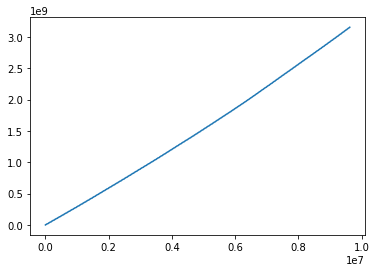

In [8]:
plt.plot(flimarray['macrotime'])
plt.show()

## Reconstructing Image from Data Stream

In [9]:
# Counting number of lines

def countLines(flimarray):
    numLinesStart = np.sum(flimarray['marker'] == 65)
    numLinesStop = np.sum(flimarray['marker'] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [10]:
FLIMInfo['LinesInFile'] = countLines(flimarray)

In [11]:
# Extracting line start and line stop positions -> Goal: slice values inbetween

lineStart = np.where(flimarray['marker'] == 65)[0]
lineStop = np.where(flimarray['marker'] == 66)[0]





# Initialize arry for intensity image
intensityImage = np.zeros((FLIMInfo['PixelsX'], FLIMInfo['PixelsY']), dtype = np.int16)

In [12]:
FLIMInfo

{'Filename': '2016-10-28_FLIM1_1_1',
 'RecordType': 16843524,
 'BitsPerRecord': 32,
 'PixelResolution': 3.7590811530208157e-07,
 'PixelsX': 512,
 'PixelsY': 512,
 'GlobalResolution': 5.1414833385090934e-08,
 'BaseResolution': 9.999999960041972e-13,
 'Resolution': 1.5999999936067155e-11,
 'BinningFactor': 16,
 'SyncRate': 19449640,
 'NumberOfRecords': 9624961,
 'LinesInFile': 51200}

In [18]:
@jit(nopython=True)
def assignNanotimes(flimarray, channel, linesinfile, pixelsx, pixelsy):
    # assign nanotimes to 3D FLIM Image array
    #flimimage = np.zeros((FLIMInfo['PixelsX'],
    #                     FLIMInfo['PixelsY'],
    #                      round(FLIMInfo['GlobalResolution'] / FLIMInfo['BaseResolution'])),
    #                    dtype = (np.int8))
    

    eventCounter = 0
    lineCounter = 0
    frameCounter = 0
    framesInFile = linesinfile / pixelsx
    
    pixelTime = 0
    
    lineStart = 0
    lineStop = 0
    
    lastLine = False
    lineActive = False
    
    
    tmpEvents = [np.float64(x) for x in range(0)]
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0
    tmpMacro = 0
    tmpNanotime = 0
    diff = 0
    
    pixelIDX = 0
    pixelIDY = 0
    
    intensityImage = np.zeros((pixelsx, pixelsy), dtype = np.int16)
    
    
    while(lastLine == False):
        tmpMarker = flimarray['marker'][eventCounter]

        if(tmpMarker == 65):
            lineActive = True
            lineStart = flimarray['macrotime'][eventCounter]
            eventCounter = eventCounter + 1
            continue
            
            
        while(lineActive == True):
            tmpMarker = flimarray['marker'][eventCounter]
            tmpMacro = flimarray['macrotime'][eventCounter]
            tmpNanotime = flimarray['nanotime'][eventCounter]
            
            
            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / pixelsy
                for photon in tmpEvents:
                    diff = photon - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    
                    if(pixelIDY < 0 or pixelIDY > (pixelIDY - 1)):
                        #print("Photon out of image range!")
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (pixelsy - 1)):
                            pixelIDY = pixelsy - 1
                            
                    intensityImage[pixelIDX][pixelIDY] = intensityImage[pixelIDX][pixelIDY] + 1
                    
                pixelIDX = pixelIDX + 1
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]
                
            eventCounter = eventCounter + 1
            
            
            
            
        eventCounter = eventCounter + 1
            
        if(lineCounter >= (pixelsx - 1)):
            #print("Finished scanning frame %d", frameCounter)
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0
            
        if(frameCounter >= framesInFile):
            lastLine = True
        
    return intensityImage

In [19]:
intImage = assignNanotimes(flimarray, 0, FLIMInfo['LinesInFile'], FLIMInfo['PixelsX'], FLIMInfo['PixelsY'])

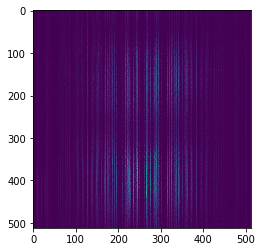

In [20]:
plt.imshow(intImage)
plt.show()

In [16]:
np.sum(intImage)

4816899

In [17]:
np.sum(flimarray['marker'] == 0)

4990911